=== One-sample t-test (Q9 > 3) ===
n=235, mean=2.506, sd=1.379, t=-5.489, df=234, p_one_sided=1.000000, d=-0.358
95% CI for mean (two-sided): [2.329, 2.684]

=== Group descriptives: Q9 by Comfort Level ===
Comfort Level   n     mean       sd
         High  64 2.406250 1.305893
          Low  60 3.083333 1.476272
       Medium 111 2.252252 1.282529

=== One-way ANOVA (Q9 ~ Comfort Level) ===
F=7.729, p=0.000563, df_between=2, df_within=232
Levene W=3.005, p=0.051456
eta^2=0.062, omega^2=0.054

=== Kruskal–Wallis ===
H=13.719, p=0.001049, epsilon^2=0.051

Saved: C:\Users\linke\OneDrive - AL-Hussien bin Abdullah Technical University\Desktop\Current research\Data Analytics portfolio\Survey project\blended_satisfaction_tests_summary.csv
Saved: C:\Users\linke\OneDrive - AL-Hussien bin Abdullah Technical University\Desktop\Current research\Data Analytics portfolio\Survey project\blended_satisfaction_group_descriptives.csv
Saved: C:\Users\linke\OneDrive - AL-Hussien bin Abdullah Technical Univ

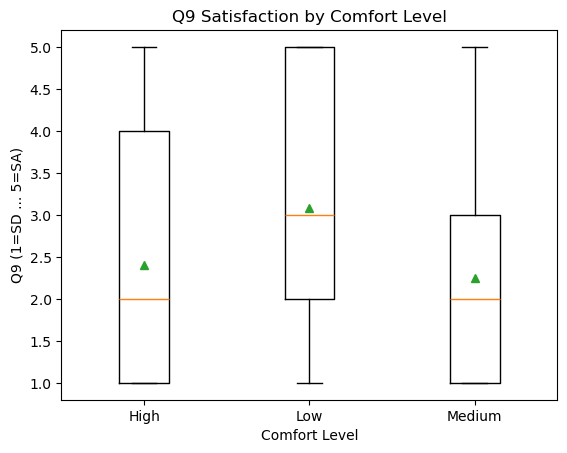

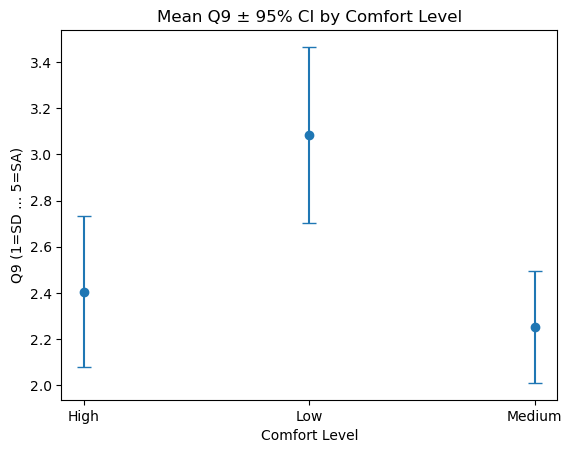

In [5]:
# ===== Blended Teaching Satisfaction — Hypothesis Tests (Jupyter version) =====
# What this cell does:
# 1) Loads your Excel file
# 2) Maps Q9 (Likert: Strongly Disagree..Strongly Agree) to 1..5
# 3) One-sample t-test vs. neutral (3), Cohen's d, 95% CI
# 4) One-way ANOVA by Comfort Level (+ Levene), eta^2, omega^2
# 5) Kruskal–Wallis fallback
# 6) Tukey HSD post-hoc (if ANOVA is applicable)
# 7) Saves CSV summaries; draws boxplot and mean+CI plot

# ---- If needed, install packages (uncomment the next two lines) ----
# !pip install pandas scipy statsmodels openpyxl
# restart the kernel if you just installed packages

import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# For Tukey’s HSD
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    STATS_MODELS_OK = True
except Exception:
    STATS_MODELS_OK = False

# For plotting
import matplotlib.pyplot as plt

# ----------------- USER PATH -----------------
EXCEL_PATH = r"C:\Users\linke\OneDrive - AL-Hussien bin Abdullah Technical University\Desktop\Current research\Data Analytics portfolio\Survey project\Blended_Teaching_Experience_Survey_Results.xlsx"
SHEET_NAME = "Sheet1"
OUT_PREFIX = "blended_satisfaction"  # used for output CSV names
# --------------------------------------------

# Likert mapping
LIKERT_MAP = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

# -------- 1) LOAD & PREP --------
p = Path(EXCEL_PATH)
if not p.exists():
    raise FileNotFoundError(f"Input file not found:\n{p}")

df = pd.read_excel(p, sheet_name=SHEET_NAME).copy()

# Basic checks
for col in ["Comfort Level", "Q9"]:
    if col not in df.columns:
        raise KeyError(f"Expected column '{col}' not found in sheet '{SHEET_NAME}'.")

# Clean + map
df["Comfort Level"] = df["Comfort Level"].astype(str).str.strip()
df["Q9_num"] = df["Q9"].astype(str).str.strip().map(LIKERT_MAP)

data = df.dropna(subset=["Q9_num"]).copy()
if data.empty:
    raise ValueError("No numeric values for Q9 after mapping Likert responses 1..5.")

# -------- 2) ONE-SAMPLE T-TEST (Q9 > 3) --------
mu0 = 3.0
x = data["Q9_num"].to_numpy(dtype=float)
n = x.size
mean_x = np.mean(x)
sd_x = np.std(x, ddof=1) if n > 1 else np.nan
t_stat, p_one_sided = stats.ttest_1samp(x, popmean=mu0, alternative="greater")

# Cohen's d and 95% CI for mean (two-sided)
cohen_d = (mean_x - mu0) / sd_x if (sd_x is not None and not np.isnan(sd_x) and sd_x != 0) else np.nan
alpha = 0.05
dfree = n - 1
if dfree > 0 and not np.isnan(sd_x) and sd_x != 0:
    t_crit = stats.t.ppf(1 - alpha/2, dfree)
    se = sd_x / np.sqrt(n)
    ci_lower = mean_x - t_crit * se
    ci_upper = mean_x + t_crit * se
else:
    ci_lower = np.nan
    ci_upper = np.nan

# -------- 3) GROUP DESCRIPTIVES BY COMFORT LEVEL --------
group_desc = (
    data.groupby("Comfort Level", dropna=False)["Q9_num"]
    .agg(n="count", mean="mean", sd="std")
    .reset_index()
    .sort_values("Comfort Level")
)

# Prepare groups for tests
groups_dict = {name: g["Q9_num"].dropna().to_numpy(dtype=float)
               for name, g in data.groupby("Comfort Level", dropna=False)}
group_names = list(groups_dict.keys())
groups = list(groups_dict.values())

# -------- 4) LEVENE + ANOVA (+ EFFECT SIZES) --------
anova_result = {}
if len(groups) >= 2 and all(len(g) > 1 for g in groups):
    levene_W, levene_p = stats.levene(*groups, center="median")
    F_stat, F_p = stats.f_oneway(*groups)

    overall = np.mean(np.concatenate(groups))
    k = len(groups)
    ssb = sum(len(g) * (np.mean(g) - overall) ** 2 for g in groups)
    ssw = sum(np.sum((g - np.mean(g)) ** 2) for g in groups)
    df_between = k - 1
    df_within = sum(len(g) - 1 for g in groups)
    ms_within = ssw / df_within if df_within > 0 else np.nan

    eta_sq = ssb / (ssb + ssw) if (ssb + ssw) > 0 else np.nan
    omega_sq = ((ssb - df_between * ms_within)
                / (ssb + ssw + ms_within)) if (ssb + ssw + ms_within) > 0 else np.nan

    anova_result = {
        "F": F_stat, "p": F_p,
        "df_between": df_between, "df_within": df_within,
        "eta_squared": eta_sq, "omega_squared": omega_sq,
        "Levene_W": levene_W, "Levene_p": levene_p
    }
else:
    anova_result = {"note": "Insufficient data per group for ANOVA (need ≥2 groups with ≥2 obs each)."}

# -------- 5) KRUSKAL–WALLIS (nonparametric) --------
if len(groups) >= 2 and all(len(g) > 0 for g in groups):
    H_stat, KW_p = stats.kruskal(*groups)
    N = sum(len(g) for g in groups)
    k = len(groups)
    eps_sq = (H_stat - k + 1) / (N - k) if (N - k) > 0 else np.nan
    kruskal_result = {"H": H_stat, "p": KW_p, "epsilon_squared": eps_sq}
else:
    kruskal_result = {"note": "Insufficient groups for Kruskal–Wallis."}

# -------- 6) TUKEY HSD (if statsmodels available and groups OK) --------
tukey_table = None
if STATS_MODELS_OK and len(groups) >= 2 and all(len(g) > 1 for g in groups):
    # Fit simple OLS for completeness (not strictly necessary for Tukey)
    model = ols("Q9_num ~ C(Comfort_Level)", data=data.rename(columns={"Comfort Level":"Comfort_Level"})).fit()
    tukey = pairwise_tukeyhsd(endog=data["Q9_num"], groups=data["Comfort Level"], alpha=0.05)
    tukey_table = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# -------- 7) SAVE CSV OUTPUTS --------
out_dir = p.parent
summary_rows = [
    {
        "Test": "One-sample t-test (Q9 > 3)",
        "n": n,
        "mean": mean_x,
        "sd": sd_x,
        "t": t_stat,
        "df": dfree,
        "p_one_sided": p_one_sided,
        "cohen_d": cohen_d,
        "95%CI_lower_mean": ci_lower,
        "95%CI_upper_mean": ci_upper
    },
    {"Test": "One-way ANOVA (Q9 ~ Comfort Level)", **anova_result},
    {"Test": "Kruskal-Wallis (Q9 ~ Comfort Level)", **kruskal_result}
]
summary_df = pd.DataFrame(summary_rows)
summary_path = out_dir / f"{OUT_PREFIX}_tests_summary.csv"
group_desc_path = out_dir / f"{OUT_PREFIX}_group_descriptives.csv"
summary_df.to_csv(summary_path, index=False)
group_desc.to_csv(group_desc_path, index=False)

if tukey_table is not None:
    tukey_path = out_dir / f"{OUT_PREFIX}_tukey_posthoc.csv"
    tukey_table.to_csv(tukey_path, index=False)
else:
    tukey_path = None

# -------- 8) PRINT RESULTS --------
print("=== One-sample t-test (Q9 > 3) ===")
print(f"n={n}, mean={mean_x:.3f}, sd={sd_x:.3f}, t={t_stat:.3f}, df={dfree}, p_one_sided={p_one_sided:.6f}, d={cohen_d:.3f}")
print(f"95% CI for mean (two-sided): [{ci_lower:.3f}, {ci_upper:.3f}]")

print("\n=== Group descriptives: Q9 by Comfort Level ===")
print(group_desc.to_string(index=False))

if "F" in anova_result:
    print("\n=== One-way ANOVA (Q9 ~ Comfort Level) ===")
    print(f"F={anova_result['F']:.3f}, p={anova_result['p']:.6f}, "
          f"df_between={anova_result['df_between']}, df_within={anova_result['df_within']}")
    print(f"Levene W={anova_result['Levene_W']:.3f}, p={anova_result['Levene_p']:.6f}")
    print(f"eta^2={anova_result['eta_squared']:.3f}, omega^2={anova_result['omega_squared']:.3f}")
else:
    print("\nANOVA not run:", anova_result.get("note", "Unknown reason."))

if "H" in kruskal_result:
    print("\n=== Kruskal–Wallis ===")
    print(f"H={kruskal_result['H']:.3f}, p={kruskal_result['p']:.6f}, epsilon^2={kruskal_result['epsilon_squared']:.3f}")
else:
    print("\nKruskal–Wallis not run:", kruskal_result.get("note", "Unknown reason."))

print(f"\nSaved: {summary_path}")
print(f"Saved: {group_desc_path}")
if tukey_path:
    print(f"Saved: {tukey_path}")

# -------- 9) PLOTS --------
# (A) Boxplot of Q9 by Comfort Level
plt.figure()
order = sorted(group_desc["Comfort Level"].unique())
data_to_plot = [data.loc[data["Comfort Level"]==lvl, "Q9_num"] for lvl in order]
plt.boxplot(data_to_plot, labels=order, showmeans=True)
plt.title("Q9 Satisfaction by Comfort Level")
plt.xlabel("Comfort Level")
plt.ylabel("Q9 (1=SD ... 5=SA)")
plt.show()

# (B) Mean ± 95% CI plot by Comfort Level
plt.figure()
means = group_desc.set_index("Comfort Level").loc[order, "mean"].to_numpy()
ns = group_desc.set_index("Comfort Level").loc[order, "n"].to_numpy()
sds = group_desc.set_index("Comfort Level").loc[order, "sd"].to_numpy()
# Std error and 95% CI
ses = sds / np.sqrt(ns)
tcrit = stats.t.ppf(1 - 0.05/2, ns - 1)
ci_low = means - tcrit * ses
ci_up  = means + tcrit * ses

xpos = np.arange(len(order))
plt.errorbar(xpos, means, yerr=[means - ci_low, ci_up - means], fmt='o', capsize=5)
plt.xticks(xpos, order)
plt.title("Mean Q9 ± 95% CI by Comfort Level")
plt.xlabel("Comfort Level")
plt.ylabel("Q9 (1=SD ... 5=SA)")
plt.show()
